# Dataset Titanic

## Descripción general

El dataset Titanic contiene información sobre los pasajeros que viajaban a bordo del RMS Titanic durante su viaje inaugural en abril de 1912. Es uno de los conjuntos de datos más utilizados en estadística, minería de datos y aprendizaje automático debido a que combina variables numéricas y categóricas, permitiendo estudiar relaciones entre características de los pasajeros y su probabilidad de supervivencia.

Una de las preguntas más comunes asociadas a este dataset es:

> ¿Qué factores influyeron en la supervivencia de los pasajeros?

Además de ser útil para clasificación, el dataset permite estudiar distribuciones empíricas, probabilidades condicionadas, dependencia entre variables, correlaciones, análisis multivariable y reducción de incertidumbre.

---

## Estructura del dataset

Cada fila representa un pasajero.

Cada columna representa una característica observada de dicho pasajero.

---

## Variables principales

### survived

Indica si el pasajero sobrevivió al desastre.

| Valor | Significado   |
| ----- | ------------- |
| 0     | No sobrevivió |
| 1     | Sobrevivió    |

Tipo: Discreta binaria

---

### pclass

Clase del boleto adquirida por el pasajero.

| Valor | Significado   |
| ----- | ------------- |
| 1     | Primera clase |
| 2     | Segunda clase |
| 3     | Tercera clase |

Tipo: Discreta ordinal

Esta variable suele considerarse una aproximación al nivel socioeconómico del pasajero.

---

### sex

Sexo del pasajero.

Valores típicos:

* male
* female

Tipo: Categórica nominal

---

### age

Edad del pasajero en años.

Tipo: Continua

Algunos registros contienen valores faltantes.

---

### sibsp

Número de hermanos o cónyuges que viajaban con el pasajero.

Tipo: Discreta

Ejemplos:

* 0: viajaba solo.
* 1: viajaba con un familiar cercano.
* 2 o más: viajaba acompañado por varios familiares.

---

### parch

Número de padres o hijos que viajaban con el pasajero.

Tipo: Discreta

Permite estudiar estructuras familiares dentro del barco.

---

### fare

Tarifa pagada por el boleto.

Tipo: Continua

Representa el costo del viaje y suele estar relacionada con la clase del pasajero.

---

### embarked

Puerto de embarque.

| Código | Puerto      |
| ------ | ----------- |
| C      | Cherbourg   |
| Q      | Queenstown  |
| S      | Southampton |

Tipo: Categórica nominal

---

### class

Versión textual de la variable `pclass`.

Valores:

* First
* Second
* Third

Tipo: Categórica ordinal

---

### who

Clasificación simplificada del pasajero.

Valores:

* man
* woman
* child

Tipo: Categórica

Esta variable combina información de edad y sexo.

---

### adult_male

Indica si el pasajero era un hombre adulto.

| Valor | Significado   |
| ----- | ------------- |
| True  | Hombre adulto |
| False | No            |

Tipo: Booleana

---

### deck

Cubierta donde se encontraba el camarote.

Valores típicos:

* A
* B
* C
* D
* E
* F
* G

Muchos registros contienen valores faltantes.

Tipo: Categórica

---

### embark_town

Nombre completo del puerto de embarque.

Ejemplos:

* Southampton
* Cherbourg
* Queenstown

Tipo: Categórica nominal

---

### alive

Versión textual de la variable `survived`.

Valores:

* yes
* no

Tipo: Categórica binaria

---

### alone

Indica si el pasajero viajaba solo.

| Valor | Significado        |
| ----- | ------------------ |
| True  | Viajaba solo       |
| False | Viajaba acompañado |

Tipo: Booleana



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================================
# Cargar dataset Titanic
# ==========================================================

df = sns.load_dataset("titanic")

print(df.head())
print(df.info())



   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64


Variable: survived
          Frecuencia  Probabilidad
survived                          
0                549      0.616162
1                342      0.383838


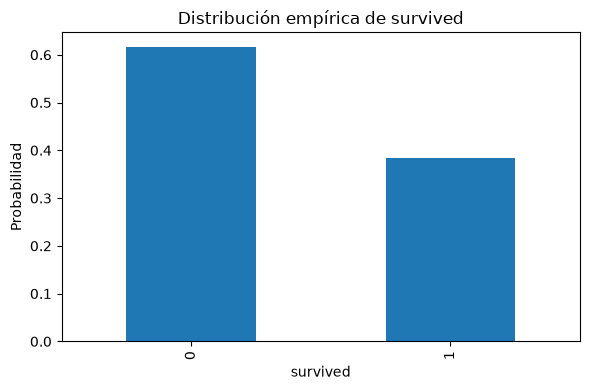


Variable: pclass
        Frecuencia  Probabilidad
pclass                          
3              491      0.551066
1              216      0.242424
2              184      0.206510


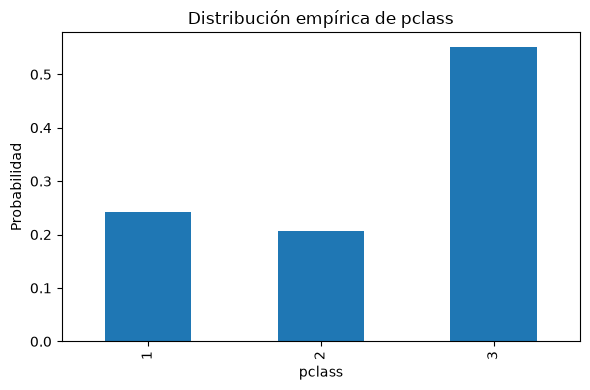


Variable: sex
        Frecuencia  Probabilidad
sex                             
male           577      0.647587
female         314      0.352413


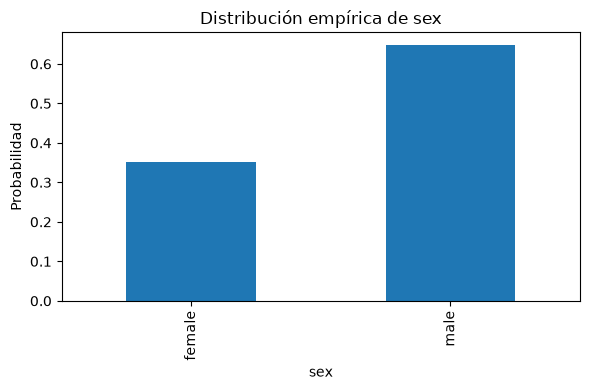


Variable: embarked
          Frecuencia  Probabilidad
embarked                          
S                644      0.722783
C                168      0.188552
Q                 77      0.086420
NaN                2      0.002245


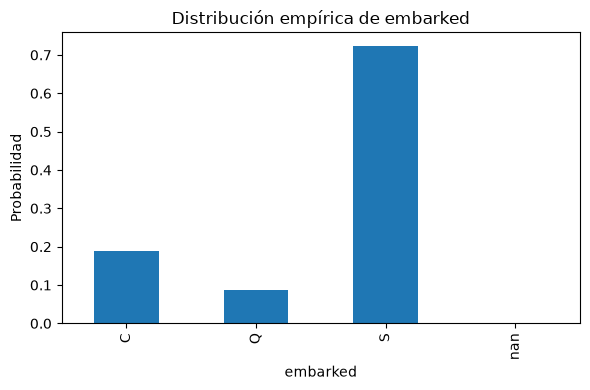


Variable: alone
       Frecuencia  Probabilidad
alone                          
True          537      0.602694
False         354      0.397306


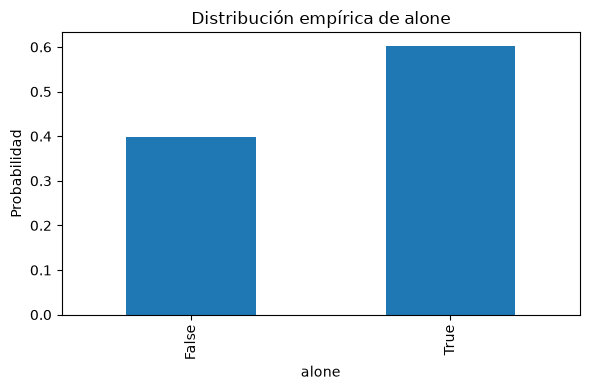

In [2]:
# ==========================================================
# Variables discretas y continuas
# ==========================================================

variables_discretas = [
    "survived",
    "pclass",
    "sex",
    "embarked",
    "alone"
]

variables_continuas = [
    "age",
    "fare"
]

# ==========================================================
# DISTRIBUCIONES EMPÍRICAS DISCRETAS
# ==========================================================

for var in variables_discretas:

    print("\n" + "="*60)
    print(f"Variable: {var}")

    # Frecuencias absolutas
    freqs = df[var].value_counts(dropna=False)

    # Probabilidades empíricas
    probs = df[var].value_counts(normalize=True, dropna=False)

    tabla = pd.DataFrame({
        "Frecuencia": freqs,
        "Probabilidad": probs
    })

    print(tabla)

    # Gráfico de probabilidades
    plt.figure(figsize=(6,4))
    probs.sort_index().plot(kind="bar")
    plt.title(f"Distribución empírica de {var}")
    plt.ylabel("Probabilidad")
    plt.tight_layout()
    plt.show()




Variable continua: age
count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64


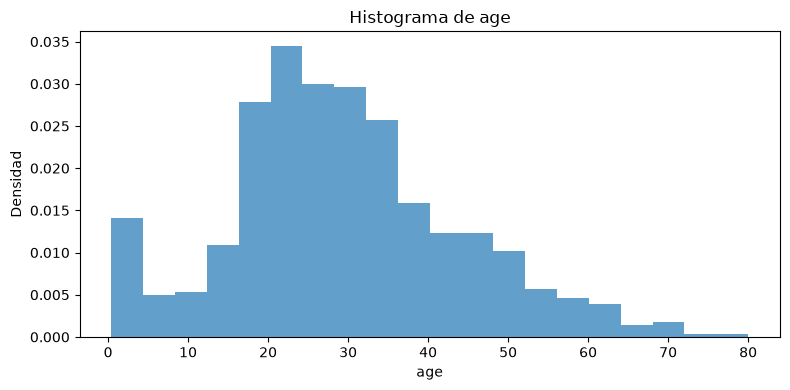


Variable continua: fare
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64


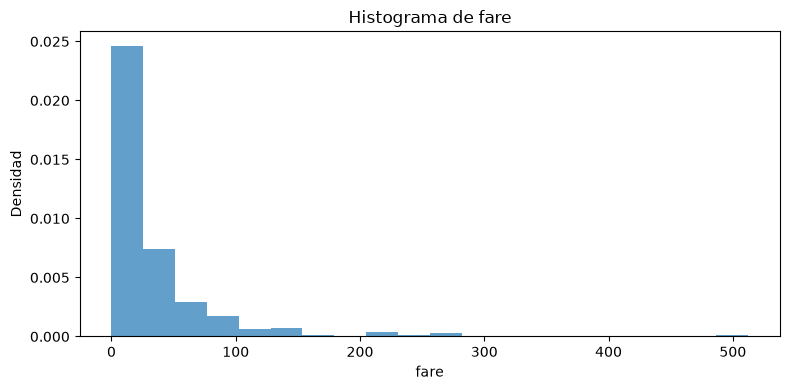


Distribución empírica discretizada de AGE
   Intervalo_inferior  Intervalo_superior  Frecuencia  Probabilidad
0               0.420               8.378          54      0.075630
1               8.378              16.336          46      0.064426
2              16.336              24.294         177      0.247899
3              24.294              32.252         169      0.236695
4              32.252              40.210         118      0.165266
5              40.210              48.168          70      0.098039
6              48.168              56.126          45      0.063025
7              56.126              64.084          24      0.033613
8              64.084              72.042           9      0.012605
9              72.042              80.000           2      0.002801

Suma probabilidades = 1.0


In [3]:

# ==========================================================
# DISTRIBUCIONES EMPÍRICAS CONTINUAS
# ==========================================================

for var in variables_continuas:

    print("\n" + "="*60)
    print(f"Variable continua: {var}")

    serie = df[var].dropna()

    print(serie.describe())

    plt.figure(figsize=(8,4))

    plt.hist(
        serie,
        bins=20,
        density=True,
        alpha=0.7
    )

    plt.title(f"Histograma de {var}")
    plt.xlabel(var)
    plt.ylabel("Densidad")
    plt.tight_layout()
    plt.show()


# ==========================================================
# DISTRIBUCIÓN EMPÍRICA CONTINUA EXPLÍCITA
# ==========================================================

# Ejemplo con edad

edad = df["age"].dropna()

hist, bins = np.histogram(
    edad,
    bins=10,
    density=False
)

probabilidades = hist / hist.sum()

tabla_edad = pd.DataFrame({
    "Intervalo_inferior": bins[:-1],
    "Intervalo_superior": bins[1:],
    "Frecuencia": hist,
    "Probabilidad": probabilidades
})

print("\nDistribución empírica discretizada de AGE")
print(tabla_edad)

# Verificación
print("\nSuma probabilidades =", probabilidades.sum())